# Implementação das operações de correlação-cruzada e convolução

## Sinal 1D

Vamos começar com um sinal unidimensional. Dado um sinal $f$ e um filtro $w$ de tamanho $a$, a correlação-cruzada para cada valor do sinal é calculada pela fórmula

\begin{equation}
g(x)=\sum_{s=0}^{a}w(s)f(x+s-\frac{a}{2})
\end{equation}

Para a implementação dessa equação, podemos pensar que $f$, $w$ e $g$ são vetores, e substituirmos $x$ e $s$ por $i$ e $j$ para representar os índices dos vetores:
\begin{equation}
g[i]=\sum_{j=0}^{a}w[j]f[i+j-\frac{a}{2}]
\end{equation}
Sendo que $a=len(w)$.


In [41]:
import numpy as np
import matplotlib.pyplot as plt

def correlation_1d(signal, w):
    """Calcula a correlação cruzada entre o sinal "signal" e o filtro "w".
    
       Parâmetros
       ----------
       signal : numpy array.
           Sinal a ser filtrado.
       w : numpy array.
           Filtro a ser utilizada na correlação cruzada.
       
       Return
       -------
       signal_filtered : numpy array
           Sinal filtrado
    """

    # Tamanho do sinal e do filtro
    num_vals = len(signal)
    a = len(w)  # Valor "a" na fórmula acima

    signal_filtered = np.zeros(num_vals)
    for i in range(num_vals):
        sum_region = 0
        for j in range(a):
            index = i + j - a // 2
            # Verifica se o índice do sinal está dentro dos limites
            if index >= 0 and index < num_vals:
                sum_region += w[j] * signal[index]
        signal_filtered[i] = sum_region

    return signal_filtered

def convolution_1d(signal, w):
    """Calcula a convolução entre o sinal e o filtro w.
    
       Parâmetros
       ----------
       signal : numpy array.
           Sinal a ser filtrado.
       w : numpy array.
           Filtro a ser utilizada na correlação cruzada.
       
       Return
       -------
       signal_filtered : numpy array, mesmo tamanho que signal
           Sinal filtrado
    """
    # Inverte o filtro. O primeiro elemento do filtro passa a ser o último, o segundo passa a 
    # ser o penúltimo, e assim por diante.
    w_inv = np.flip(w)

    signal_filtered = correlation_1d(signal, w_inv)

    return signal_filtered

In [42]:
# Vamos criar um sinal 1D artificial. 
signal = np.array([2, 3, 1, 4, 3, 2, 1, 1, 2])
w = np.array([1, 2, 3])
signal_filtered = correlation_1d(signal, w)
print(signal_filtered)

[13. 11. 17. 18. 16. 10.  7.  9.  5.]


Comparação entre correlação e convolução

In [43]:
# Sinal contendo zeros e um único valor 1
signal = np.array([0, 0, 0, 0, 1, 0, 0, 0, 0])
w = np.array([1, 2, 3, 4])
print(correlation_1d(signal, w))
print(convolution_1d(signal, w))

[0. 0. 0. 4. 3. 2. 1. 0. 0.]
[0. 0. 0. 1. 2. 3. 4. 0. 0.]


Como exemplo, vamos extrair uma linha de uma imagem e considerá-la como um sinal 1D:

Text(0.5, 1.0, 'Sinal 1D extraído da linha 100 da imagem')

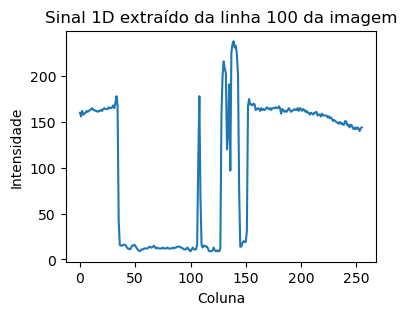

In [44]:
img = plt.imread("../../dados/cameraman.tiff")
signal = img[100]
plt.plot(signal)
plt.xlabel("Coluna")
plt.ylabel("Intensidade")
plt.title("Sinal 1D extraído da linha 100 da imagem")

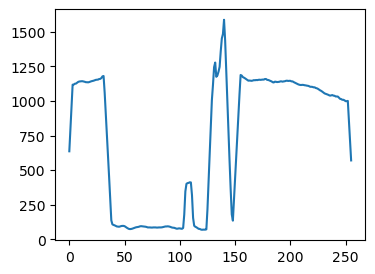

In [45]:
# Filtro de tamanho 7 com todos os elementos iguais a 1.
w = np.array([1, 1, 1, 1, 1, 1, 1])
signal_filtered = convolution_1d(signal, w)
plt.plot(signal_filtered)

## Sinal 2D (imagem)

Dada uma imagem $f$ e um filtro $w$ de tamanho $a\times b$, a correlação-cruzada para cada pixel $(x,y)$ da imagem é calculada pela fórmula

\begin{equation}
g(x,y)=\sum_{s=0}^{a}\sum_{t=0}^{b}w(s,t)f(x+s-\frac{a}{2}, y+t-\frac{b}{2})
\end{equation}

Considerando que $f$, $w$ e $g$ são matrizes, vamos chamar $x$ e $y$ de $i$ e $j$ pois eles são índices. $s$ e $t$ também são índices, mas vamos manter os mesmos nomes. Vamos também chamar $f$ de $img$. Com isso:

\begin{equation}
g[i,j]=\sum_{s=0}^{a}\sum_{t=0}^{b}w[s,t]f[i+s-\frac{a}{2}, j+t-\frac{b}{2}]
\end{equation}
Sendo que $a$ é o número de linhas do filtro e $b$ o número de colunas.

In [46]:
import numpy as np

def correlation(img, w):
    """Calcula a correlação cruzada entre a imagem img e o filtro w.
    
       Parâmetros
       ----------
       img : numpy array.
           Imagem a ser filtrada.
       w : numpy array.
           Filtro a ser utilizada na correlação cruzada.
       
       Return
       -------
       img_filtered : numpy array, mesmo tamanho que img
           Imagem filtrada
    """

    num_rows, num_cols = img.shape
    a, b = w.shape      # num_rows_f=a+1 e num_cols_f=b+1 (a e b na fórmula acima)

    img_filtered = np.zeros((num_rows, num_cols))
    for i in range(num_rows):
        for j in range(num_cols):
            sum_region = 0
            for s in range(a):
                for t in range(b):
                    row = i + s - a // 2
                    col = j + t - b // 2
                    # Verifica se os índices estão dentro dos limites da imagem
                    if row >= 0 and row < num_rows and col >= 0 and col < num_cols:
                        sum_region += w[s, t]*img[i+s-a//2, j+t-b//2]
            img_filtered[i, j] = sum_region

    return img_filtered

def convolution(img, w):
    """Calcula a convolução entre a imagem img e o filtro w.
    
       Parâmetros
       ----------
       img : numpy array.
           Imagem a ser filtrada.
       w : numpy array.
           Filtro a ser utilizada na correlação cruzada.
       
       Return
       -------
       img_filtered : numpy array, mesmo tamanho que img
           Imagem filtrada
    """
    # Inverte o filtro
    w_inv = np.flip(w)

    img_filtered = correlation(img, w_inv)

    return img_filtered

Text(0.5, 1.0, 'Imagem filtrada com o filtro w')

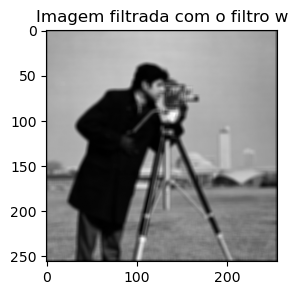

In [47]:
w = np.ones((5,5))
img_filtered = convolution(img, w)

plt.imshow(img_filtered, cmap="gray")
plt.title("Imagem filtrada com o filtro w")

## Convolução usando scipy

A biblioteca scipy possui a função `convolve`, que realiza a convolução entre dois sinais.

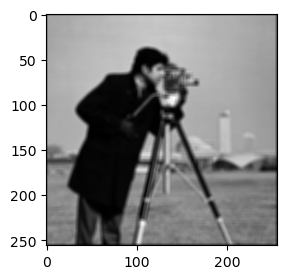

In [50]:
from scipy.signal import convolve

img_filtered = convolve(img, w, mode="same")
plt.imshow(img_filtered, cmap="gray")